# DAMADICS Actuator Benchmark — Exploration & Visualization

## Dataset Overview

The **DAMADICS (Development and Application of Methods for Actuator Diagnosis in Industrial Control Systems)** benchmark contains real process data from the **Lublin Sugar Factory** in Poland. It captures measurements from industrial actuators used in a sugar production process, designed for fault detection and isolation (FDI) research.

### Key Characteristics
| Property | Value |
|---|---|
| **Source** | Lublin Sugar Factory, Poland (real industrial data) |
| **Total Samples** | 86,400 per day (1 Hz sampling) |
| **Dimensions** | 32 process variables |
| **Days** | 25 days of continuous operation |
| **Faults** | Known fault injection on Nov 15, 2001 |
| **Domain** | Industrial Process Control / Sugar Manufacturing |

### Research Relevance for Industry 5.0
- **Anomaly Detection**: Known fault injection date enables evaluation of unsupervised AD
- **Clustering**: Multiple operational regimes (day/night, production phases, weekends)
- **Predictive Maintenance**: Incipient fault detection — faults develop gradually before becoming critical
- **Classic Industrial Benchmark**: Well-established in the FDI community, still actively used

### DAMADICS Variable Descriptions
| Index | Description |
|---|---|
| 0 | Time (seconds from midnight) |
| 1 | CV (Control Valve position) |
| 2 | P1 (Upstream pressure) |
| 3 | P2 (Downstream pressure) |
| 4-6 | Temperature measurements |
| 7-32 | Additional process variables |


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (16, 6)
plt.rcParams['font.size'] = 11

DATA_DIR = 'damadics'

# Load all daily files
files = sorted([f for f in os.listdir(DATA_DIR) if f.endswith('.txt')])
print(f"Available daily files: {len(files)}")
print(f"Date range: {files[0]} to {files[-1]}")

# Parse dates from filenames (format: DDMMYYYY.txt)
dates = []
for f in files:
    name = f.replace('.txt', '')
    day, month, year = int(name[:2]), int(name[2:4]), int(name[4:])
    dates.append(f"{year}-{month:02d}-{day:02d}")
    
print(f"\nDates: {dates}")


Available daily files: 25
Date range: 01112001.txt to 31102001.txt

Dates: ['2001-11-01', '2001-11-02', '2001-11-03', '2001-11-04', '2001-11-05', '2001-11-06', '2001-11-07', '2001-11-08', '2001-11-09', '2001-11-10', '2001-11-11', '2001-11-12', '2001-11-13', '2001-11-14', '2001-11-15', '2001-11-16', '2001-11-17', '2001-11-18', '2001-11-19', '2001-11-20', '2001-11-21', '2001-11-22', '2001-10-29', '2001-10-30', '2001-10-31']


In [2]:
# Load all data into a single DataFrame
all_data = []
day_labels = []

for i, f in enumerate(files):
    filepath = os.path.join(DATA_DIR, f)
    data = np.loadtxt(filepath)
    all_data.append(data)
    day_labels.extend([i] * len(data))

all_data = np.vstack(all_data)
day_labels = np.array(day_labels)

# Create column names
col_names = ['Time_sec'] + [f'Var_{j}' for j in range(1, all_data.shape[1])]

df = pd.DataFrame(all_data, columns=col_names)
df['Day_Index'] = day_labels
df['Date'] = [dates[d] for d in day_labels]

print(f"=== DAMADICS Dataset Summary ===")
print(f"Total samples: {len(df):,}")
print(f"Dimensions: {all_data.shape[1]} (including time)")
print(f"Days: {len(files)}")
print(f"Samples per day: {len(df) // len(files):,}")
print(f"\nColumn statistics:")
print(df[col_names].describe().round(2))


=== DAMADICS Dataset Summary ===
Total samples: 2,160,000
Dimensions: 33 (including time)
Days: 25
Samples per day: 86,400

Column statistics:


         Time_sec       Var_1       Var_2       Var_3       Var_4       Var_5  \
count  2160000.00  2160000.00  2160000.00  2160000.00  2160000.00  2160000.00   
mean     43199.50      645.30      353.39       96.57      357.36       34.87   
std      24941.54       37.22       25.70        1.25       21.05        4.46   
min          0.00      381.70        0.70       69.60      198.50        0.10   
25%      21599.75      628.30      338.00       96.00      346.80       32.80   
50%      43199.50      646.90      354.60       96.70      359.80       34.60   
75%      64799.25      665.70      370.00       97.30      371.20       36.40   
max      86399.00      812.90      445.20       99.50      437.20      100.00   

            Var_6       Var_7       Var_8       Var_9  ...      Var_23  \
count  2160000.00  2160000.00  2160000.00  2160000.00  ...  2160000.00   
mean        34.15       47.74      128.95      133.11  ...     3309.38   
std          4.32        1.54        1.07       

## 1. Multi-Day Process Overview

The DAMADICS data spans 25 days of continuous sugar factory operation. Each day has 86,400 samples (1 sample per second, 24 hours). Below we visualize the full temporal evolution of key process variables.


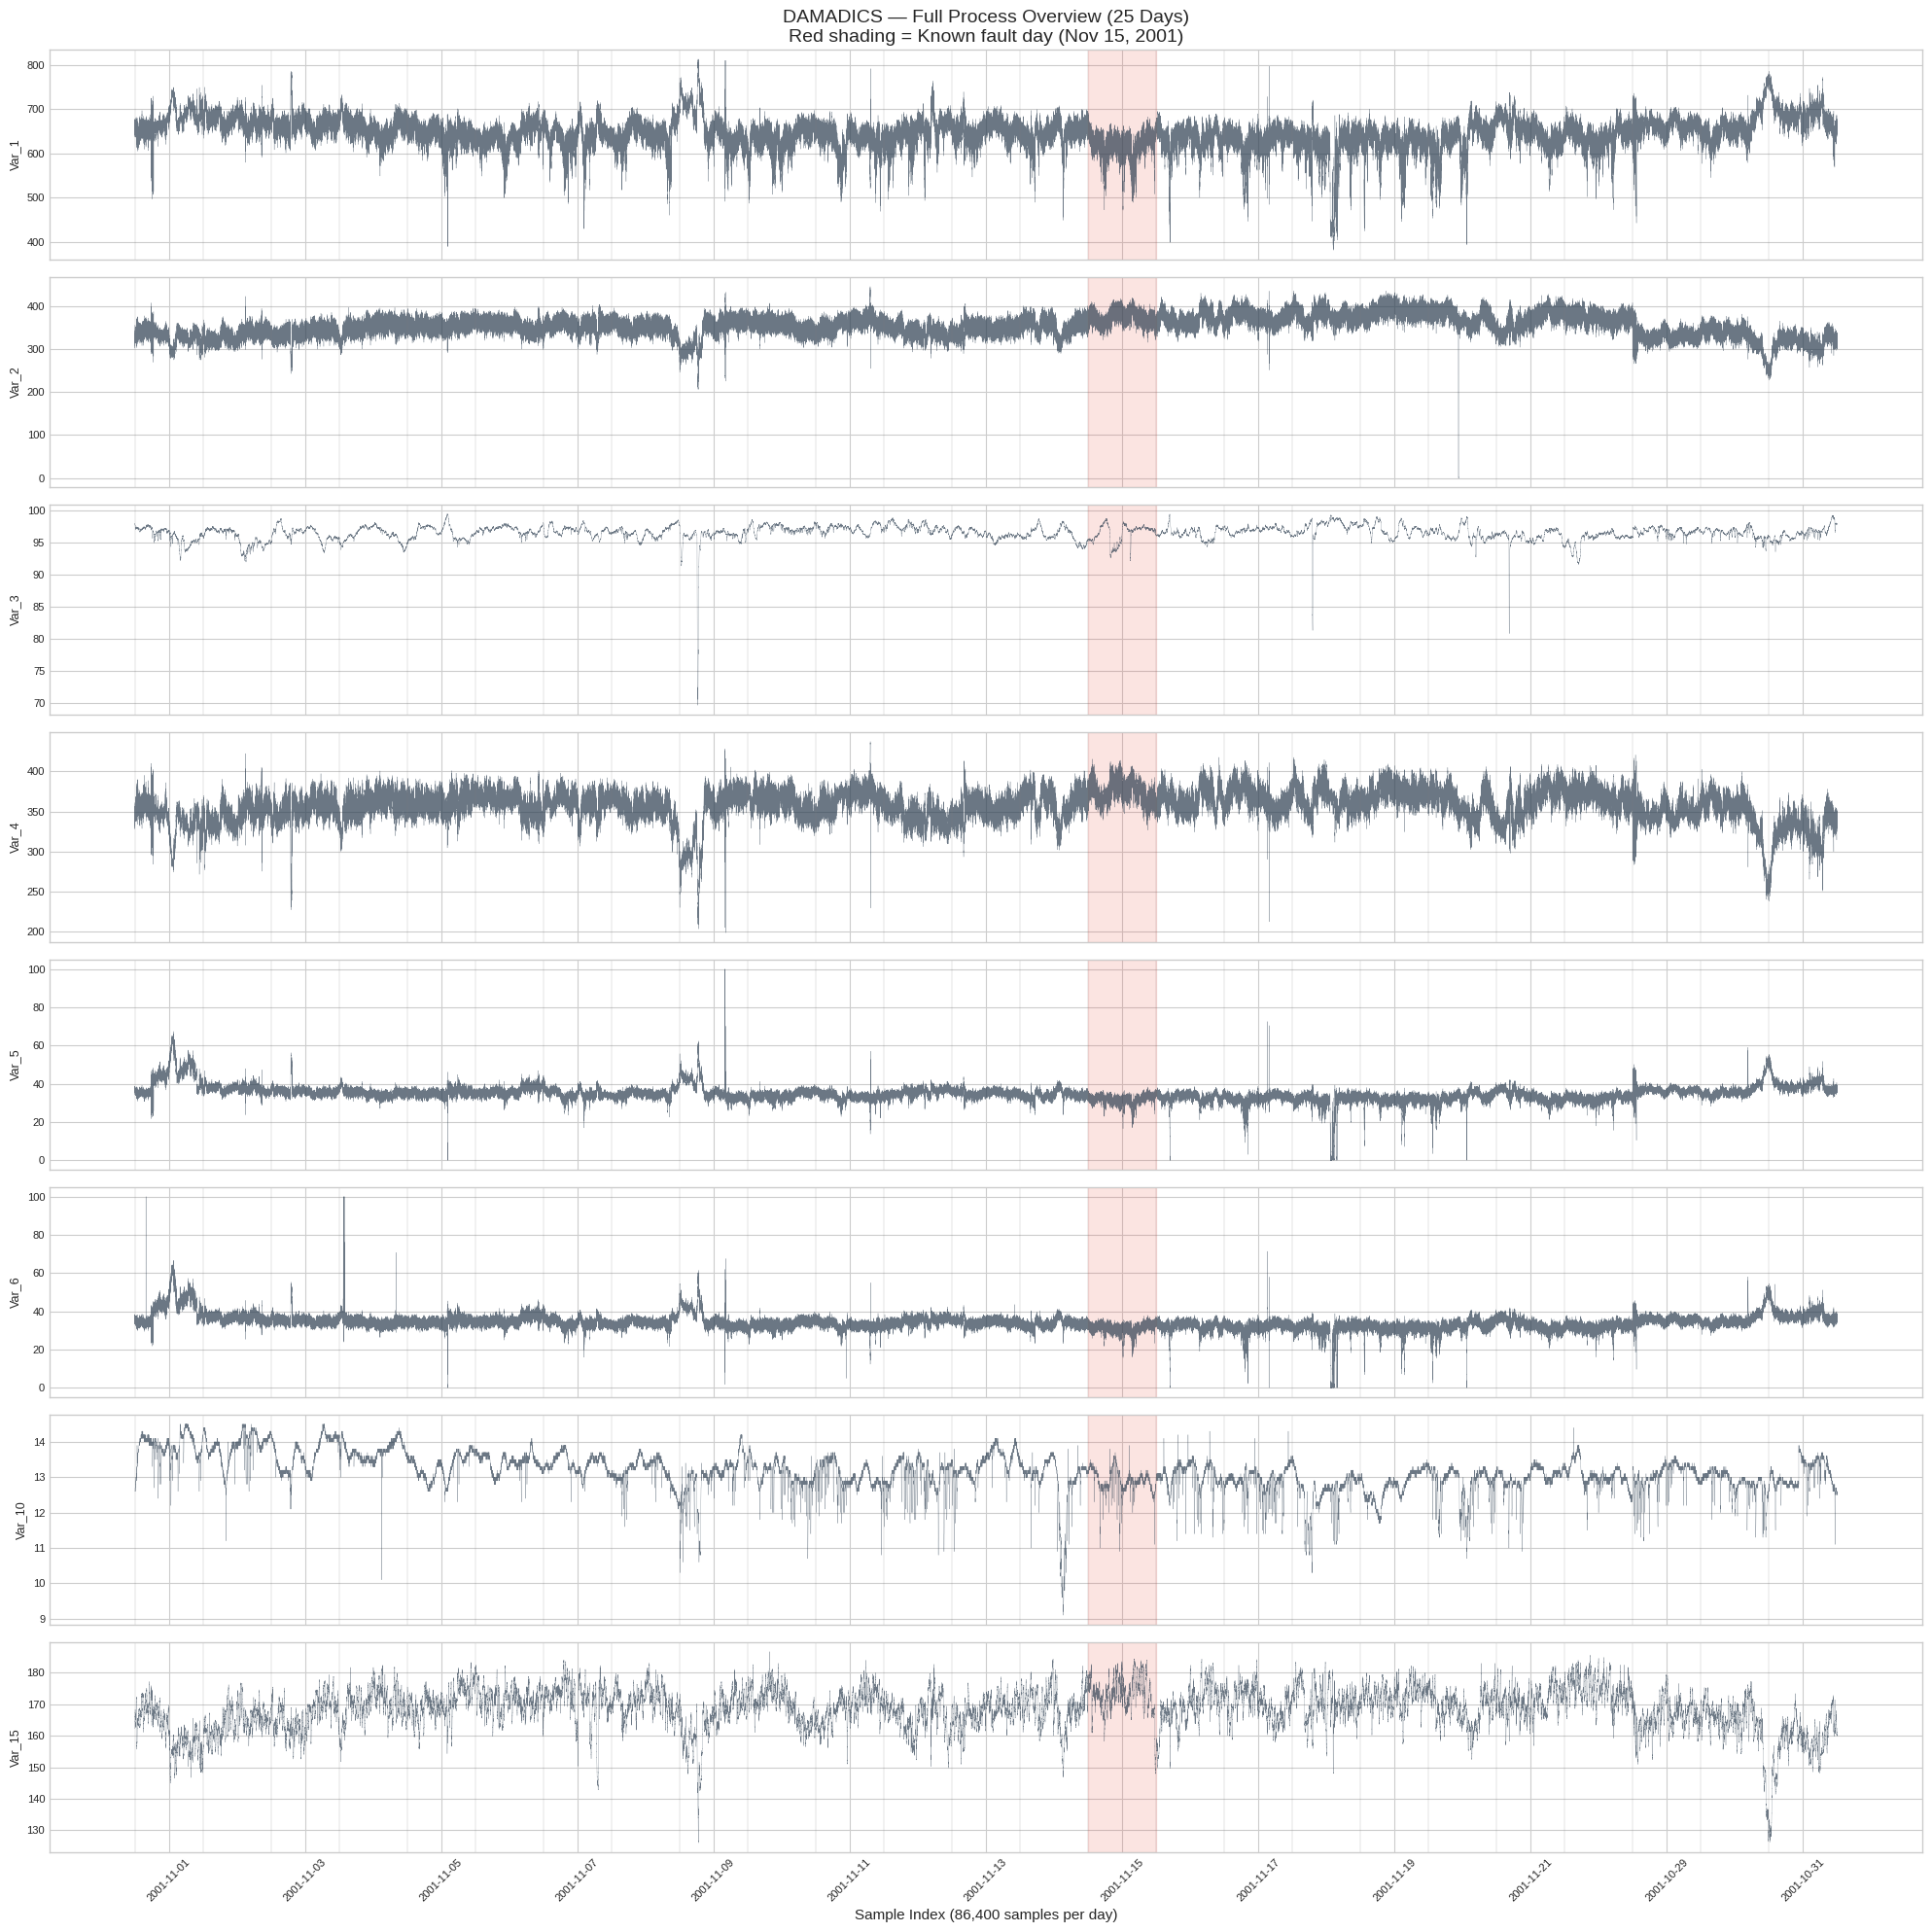

Known fault injection date: 2001-11-15 (day index 14)
The fault day shows distinct patterns in several process variables.


In [3]:
# Visualize key process variables across all days
key_vars = ['Var_1', 'Var_2', 'Var_3', 'Var_4', 'Var_5', 'Var_6', 'Var_10', 'Var_15']

fig, axes = plt.subplots(len(key_vars), 1, figsize=(20, 2.5 * len(key_vars)), sharex=True)

# Known fault date: November 15, 2001
fault_date = '2001-11-15'
fault_day_idx = dates.index(fault_date) if fault_date in dates else -1

total_samples = len(df)
for i, var in enumerate(key_vars):
    ax = axes[i]
    ax.plot(range(total_samples), df[var].values, linewidth=0.2, color='#2c3e50', alpha=0.7)
    ax.set_ylabel(var, fontsize=9)
    ax.tick_params(labelsize=8)
    
    # Mark day boundaries
    for d in range(len(files)):
        day_start = d * 86400
        ax.axvline(x=day_start, color='gray', linewidth=0.3, alpha=0.5)
    
    # Highlight fault day
    if fault_day_idx >= 0:
        fault_start = fault_day_idx * 86400
        fault_end = (fault_day_idx + 1) * 86400
        ax.axvspan(fault_start, fault_end, alpha=0.15, color='#e74c3c')

# Add date labels
axes[-1].set_xlabel('Sample Index (86,400 samples per day)')
day_positions = [d * 86400 + 43200 for d in range(len(files))]
axes[-1].set_xticks(day_positions[::2])
axes[-1].set_xticklabels([dates[d] for d in range(0, len(dates), 2)], rotation=45, fontsize=8)

axes[0].set_title('DAMADICS — Full Process Overview (25 Days)\nRed shading = Known fault day (Nov 15, 2001)', fontsize=14)
plt.tight_layout()
plt.show()
print(f"Known fault injection date: {fault_date} (day index {fault_day_idx})")
print("The fault day shows distinct patterns in several process variables.")


## 2. Daily Operational Patterns — Clustering Potential

Each day of operation has its own characteristic pattern. Some days show similar behavior (e.g., normal production days), while others differ (weekends, maintenance, fault days). This creates a natural basis for **day-level clustering**.


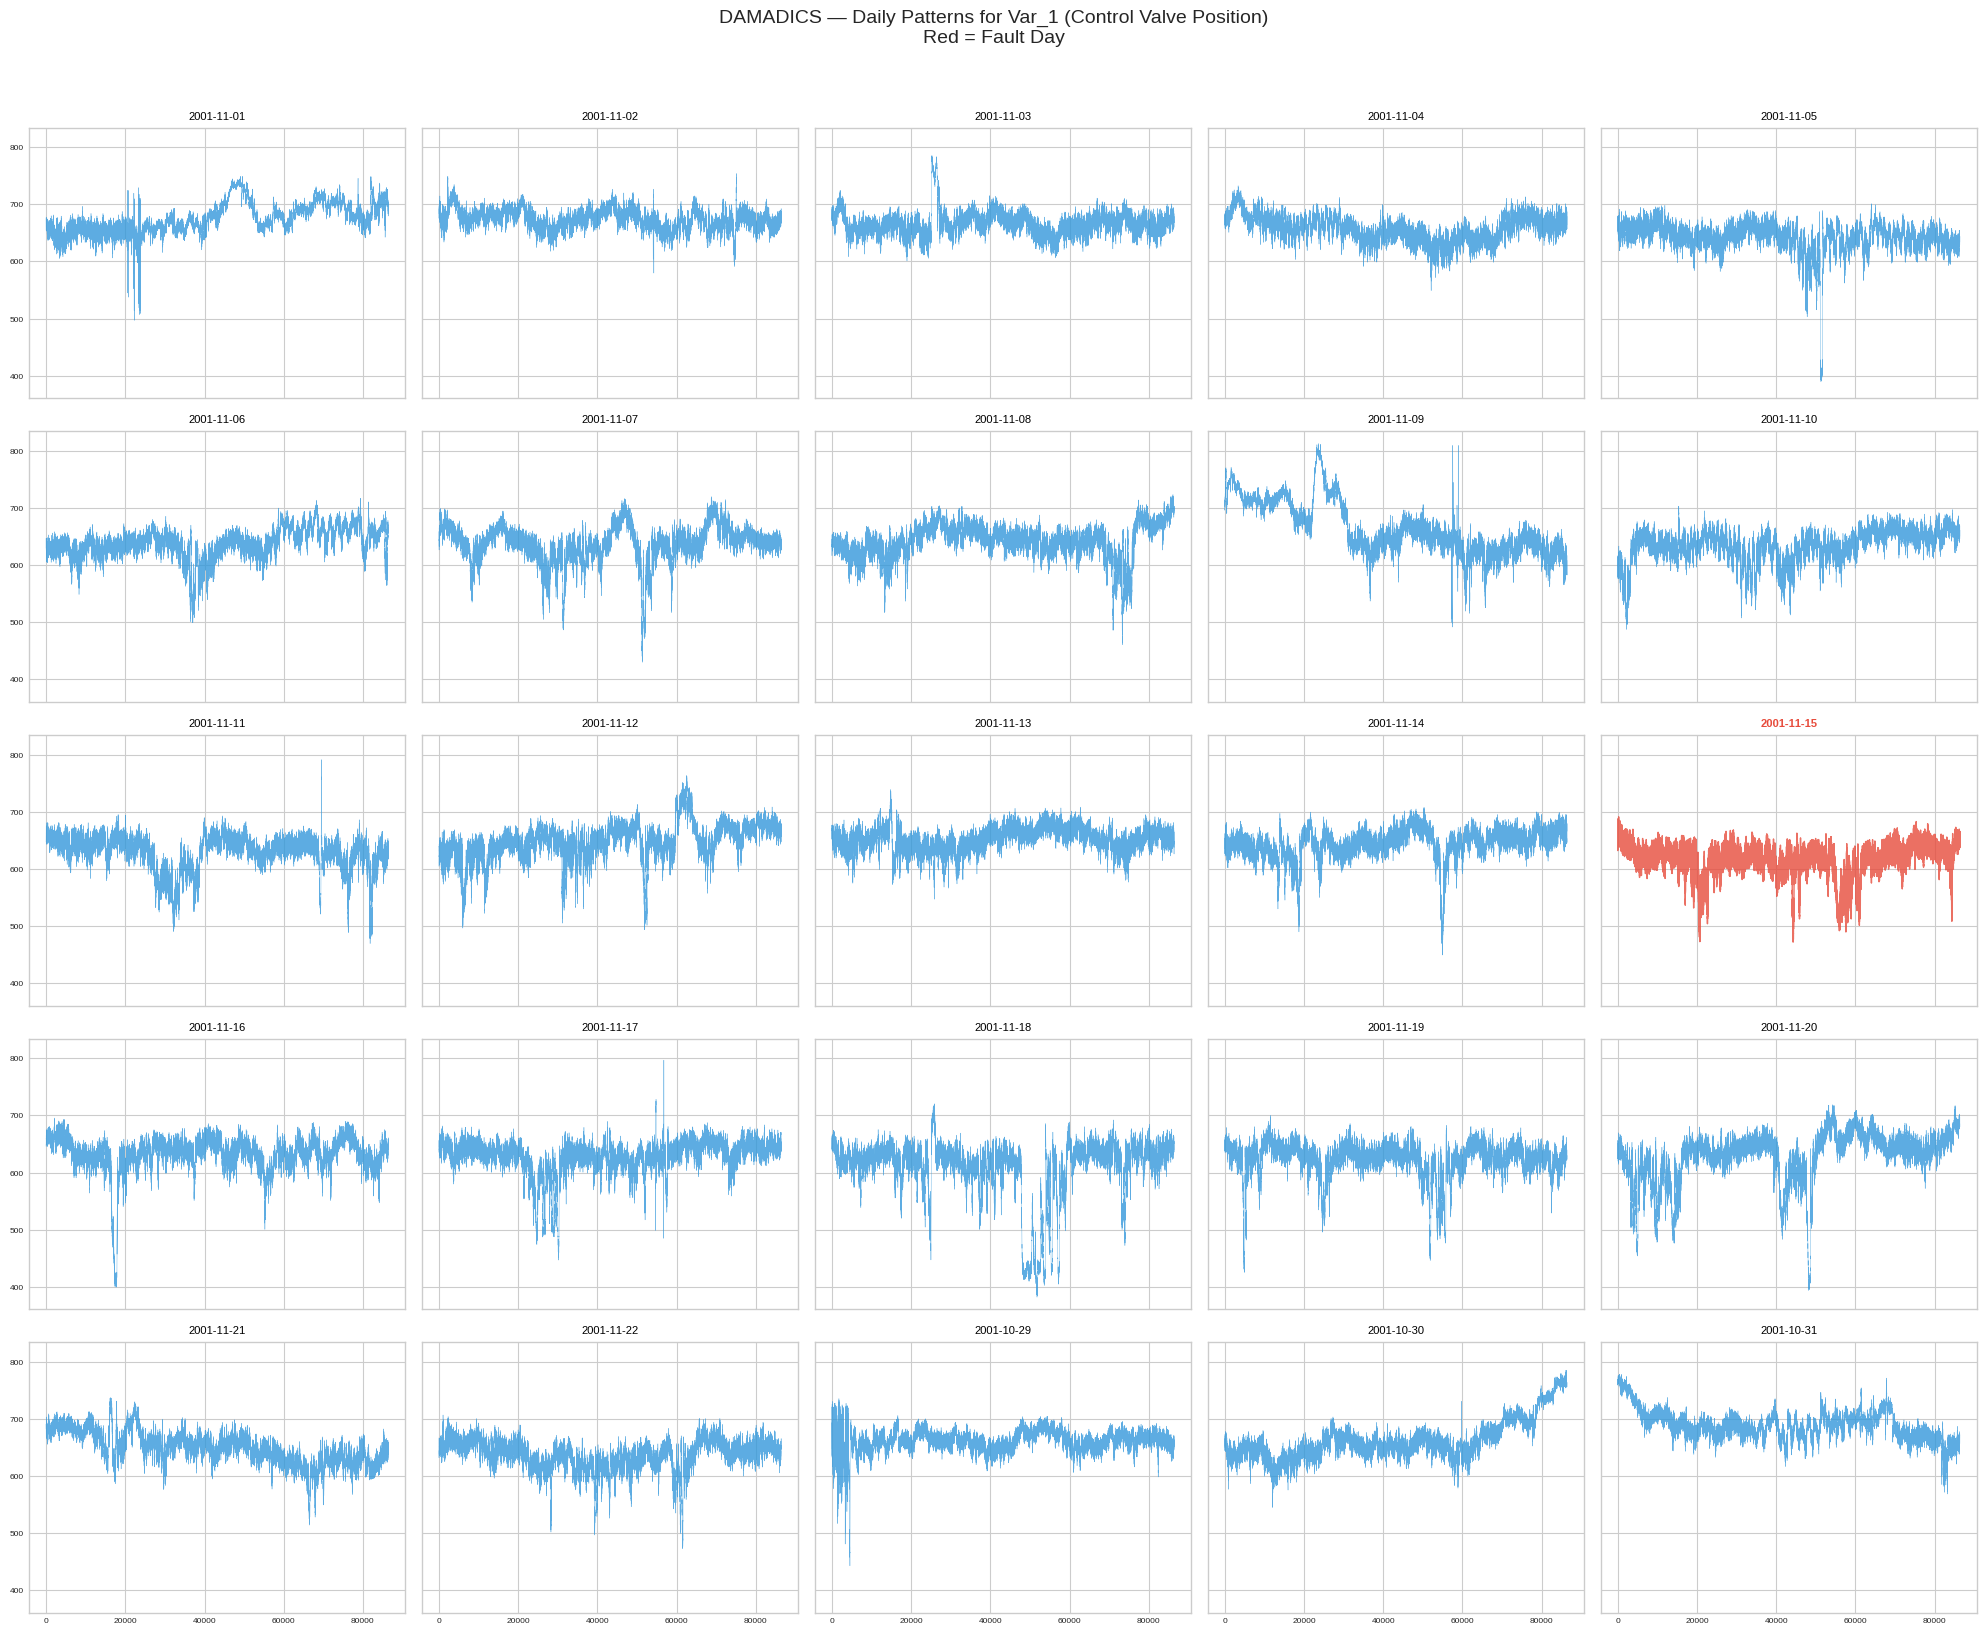

Key Insight: Daily patterns show significant variation — some days have similar
operational profiles while others differ. This supports day-level clustering research.


In [4]:
# Compare daily patterns for a key variable
fig, axes = plt.subplots(5, 5, figsize=(20, 16), sharex=True, sharey=True)
axes = axes.flatten()

var = 'Var_1'  # Control valve position

for i, (f, date) in enumerate(zip(files, dates)):
    ax = axes[i]
    day_data = df[df['Day_Index'] == i]
    
    color = '#e74c3c' if date == fault_date else '#3498db'
    linewidth = 1.0 if date == fault_date else 0.3
    
    ax.plot(day_data['Time_sec'].values, day_data[var].values, 
            linewidth=linewidth, color=color, alpha=0.8)
    ax.set_title(date, fontsize=8, color=color if date == fault_date else 'black',
                fontweight='bold' if date == fault_date else 'normal')
    ax.tick_params(labelsize=6)

plt.suptitle(f'DAMADICS — Daily Patterns for {var} (Control Valve Position)\nRed = Fault Day', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()
print("Key Insight: Daily patterns show significant variation — some days have similar")
print("operational profiles while others differ. This supports day-level clustering research.")


## 3. Fault Day Analysis — Anomaly Detection Target

November 15, 2001 is the known fault injection date. Comparing this day with normal days reveals the anomaly signatures that unsupervised methods should detect.


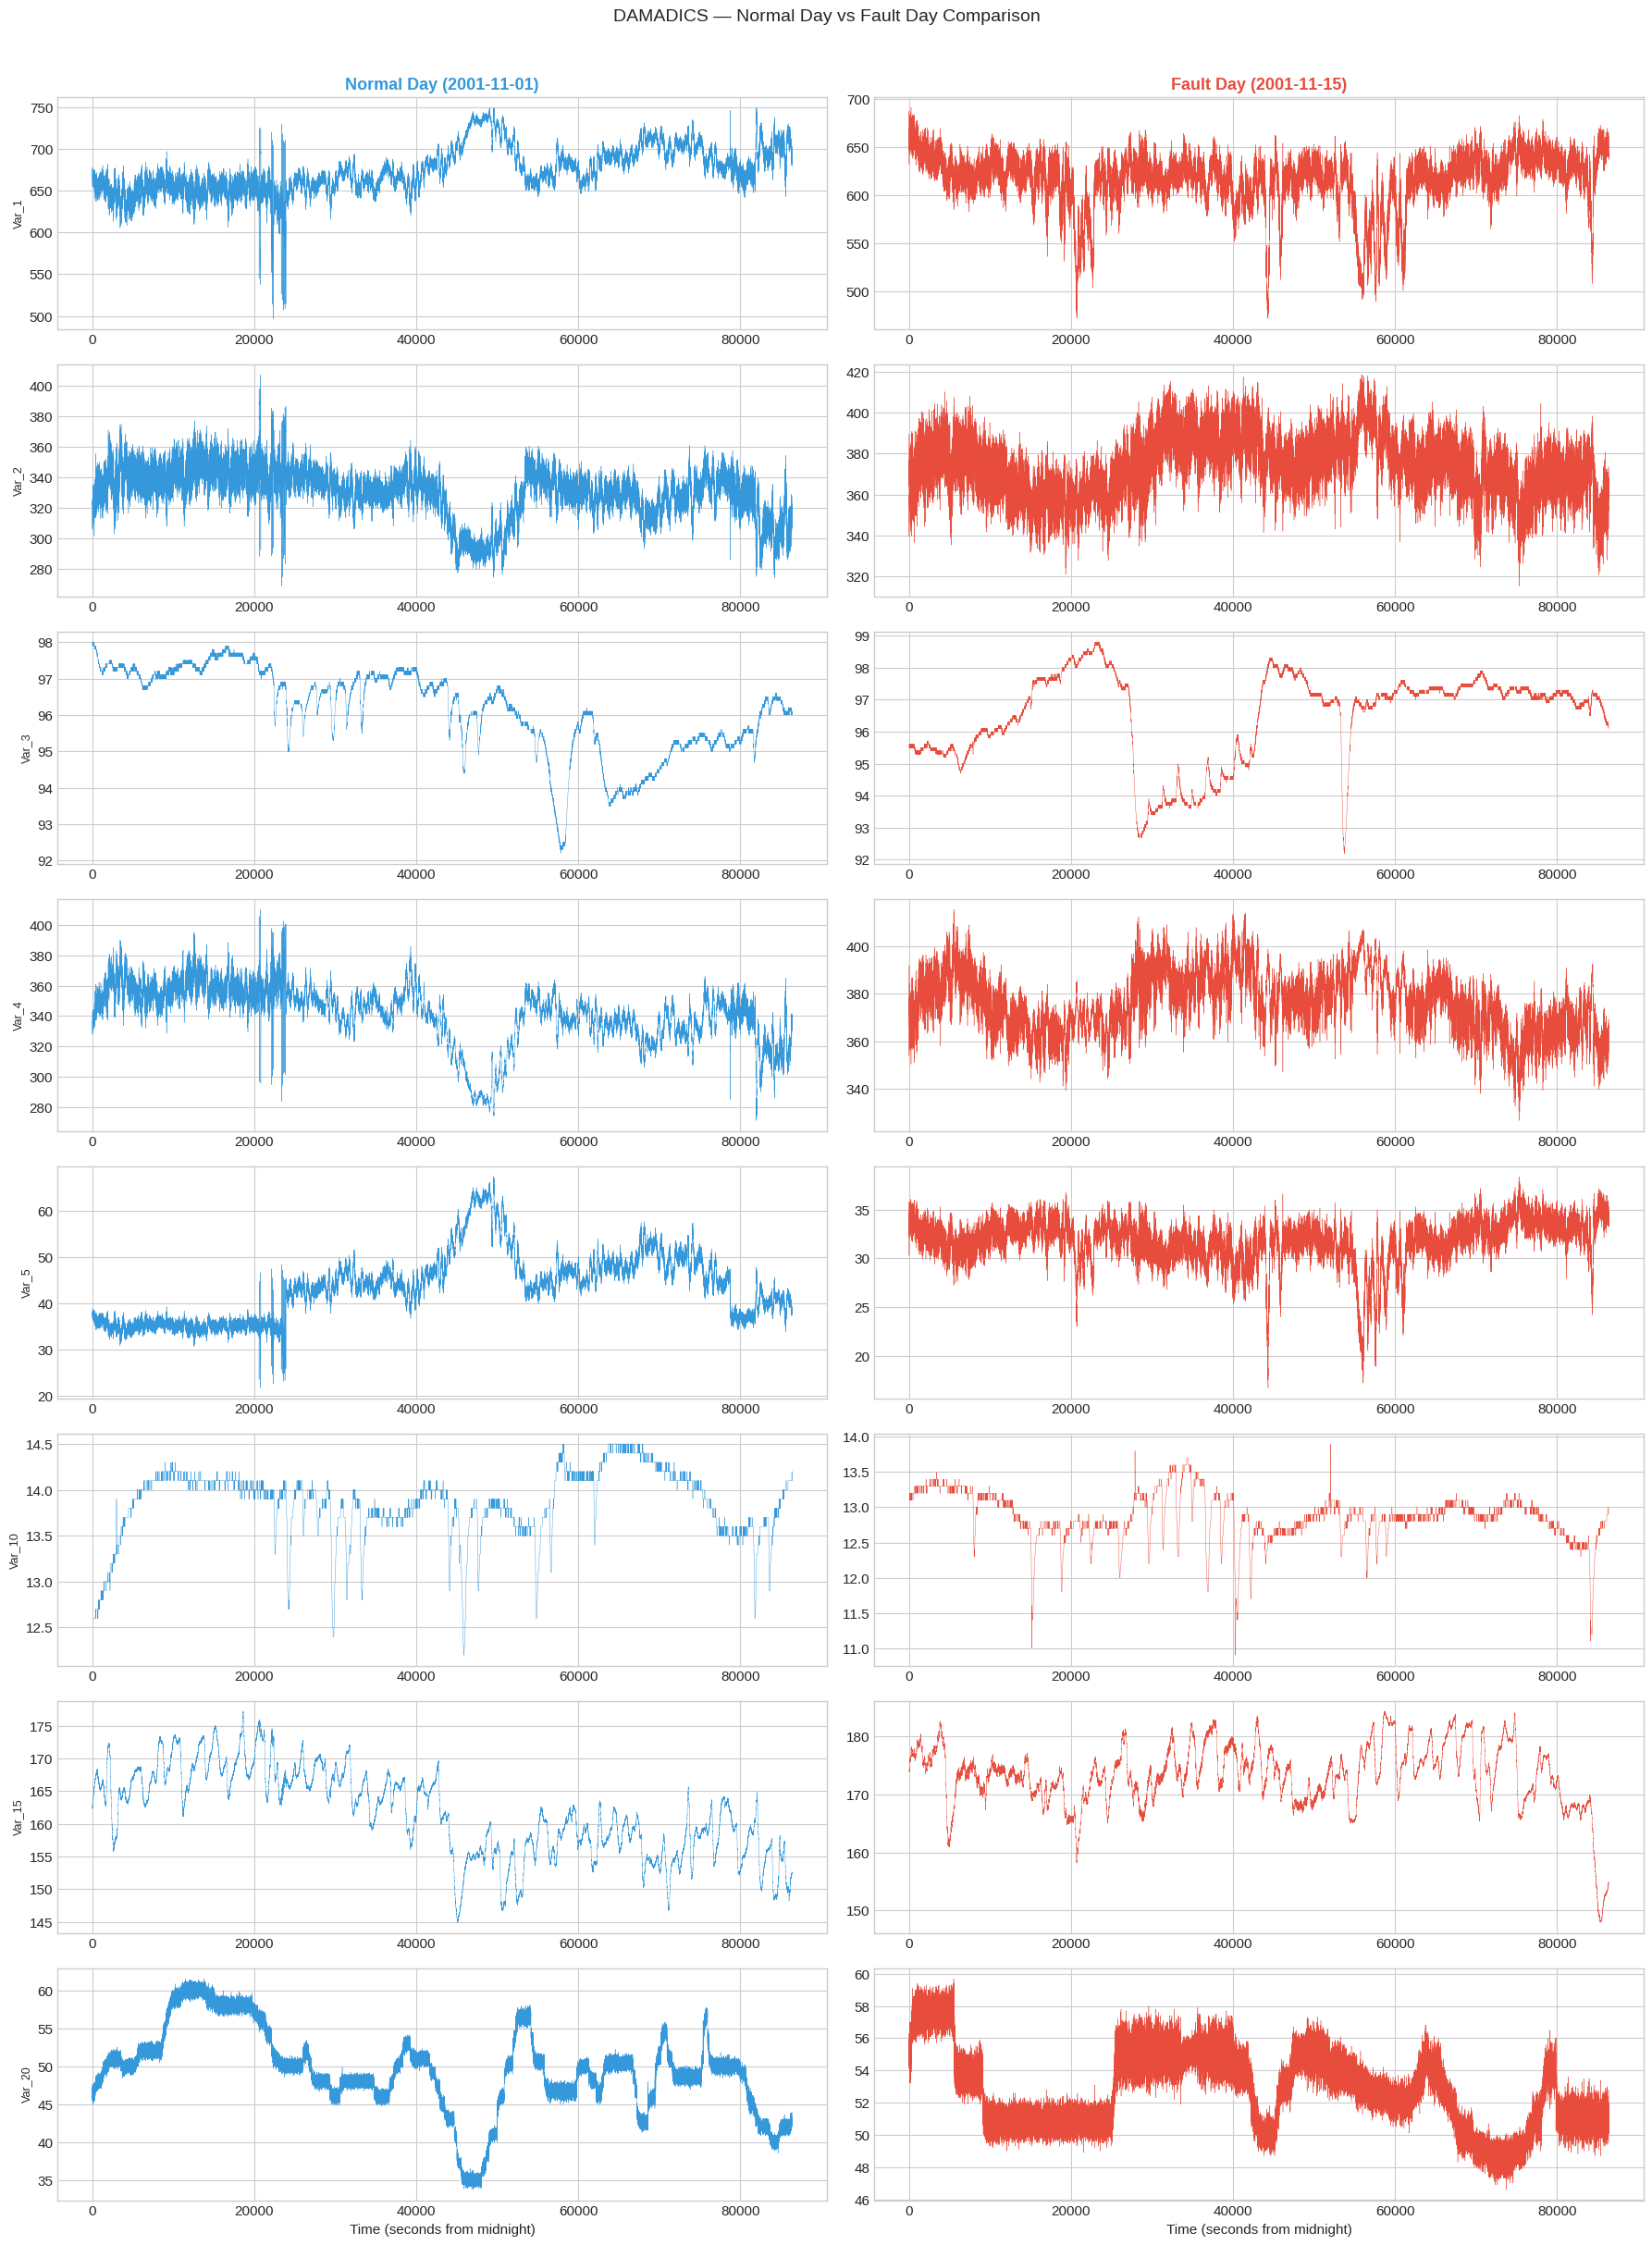

Key Insight: The fault manifests differently across variables.
Some variables show clear deviations while others appear normal —
this makes multivariate analysis essential for reliable detection.


In [5]:
# Compare fault day with a normal day
normal_day_idx = 0  # First day (Oct 27)
fault_day_idx_val = dates.index(fault_date) if fault_date in dates else -1

normal_day = df[df['Day_Index'] == normal_day_idx]
fault_day = df[df['Day_Index'] == fault_day_idx_val] if fault_day_idx_val >= 0 else None

selected_vars = ['Var_1', 'Var_2', 'Var_3', 'Var_4', 'Var_5', 'Var_10', 'Var_15', 'Var_20']

fig, axes = plt.subplots(len(selected_vars), 2, figsize=(18, 3 * len(selected_vars)))

for i, var in enumerate(selected_vars):
    # Normal day
    axes[i][0].plot(normal_day['Time_sec'].values, normal_day[var].values, 
                    linewidth=0.3, color='#3498db')
    axes[i][0].set_ylabel(var, fontsize=9)
    if i == 0:
        axes[i][0].set_title(f'Normal Day ({dates[normal_day_idx]})', fontsize=13, 
                             fontweight='bold', color='#3498db')
    
    # Fault day
    if fault_day is not None:
        axes[i][1].plot(fault_day['Time_sec'].values, fault_day[var].values, 
                        linewidth=0.3, color='#e74c3c')
        if i == 0:
            axes[i][1].set_title(f'Fault Day ({fault_date})', fontsize=13, 
                                 fontweight='bold', color='#e74c3c')

axes[-1][0].set_xlabel('Time (seconds from midnight)')
axes[-1][1].set_xlabel('Time (seconds from midnight)')
plt.suptitle('DAMADICS — Normal Day vs Fault Day Comparison', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()
print("Key Insight: The fault manifests differently across variables.")
print("Some variables show clear deviations while others appear normal —")
print("this makes multivariate analysis essential for reliable detection.")


## 4. Feature Correlation Structure

The 32 process variables capture different aspects of the sugar production process. Understanding their correlation structure is essential for multivariate anomaly detection methods.


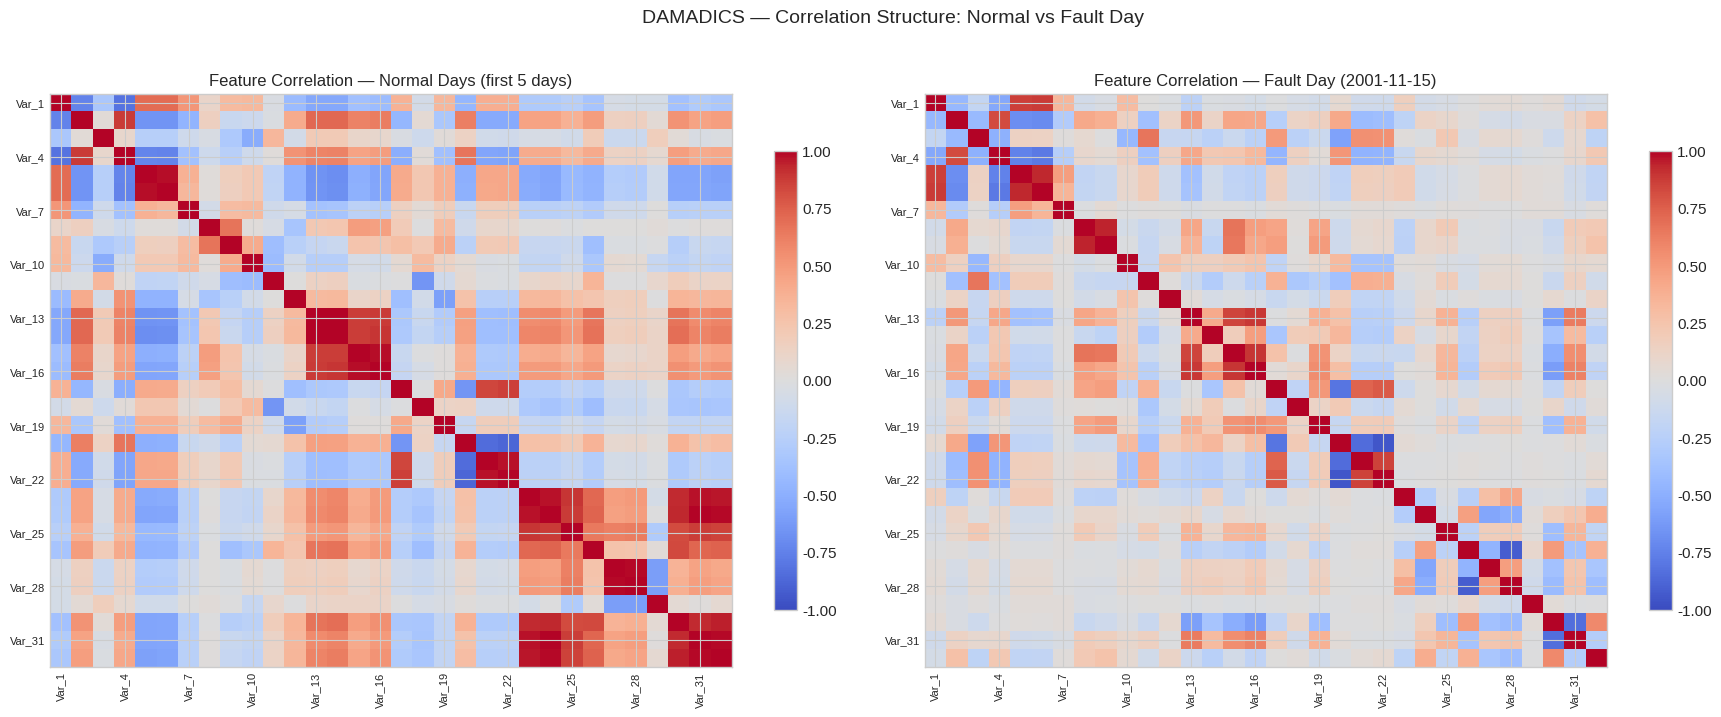

Key Insight: The fault disrupts the normal correlation structure between process variables.
Reconstruction-based methods can leverage this change for anomaly detection.


In [6]:
# Correlation analysis: normal days vs fault day
process_vars = [c for c in col_names if c != 'Time_sec']

# Normal days correlation (use first 5 days)
normal_data = df[df['Day_Index'].isin(range(5))][process_vars]
corr_normal = normal_data.corr()

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

im1 = axes[0].imshow(corr_normal.values, cmap='coolwarm', vmin=-1, vmax=1, aspect='auto')
axes[0].set_title('Feature Correlation — Normal Days (first 5 days)', fontsize=12)
axes[0].set_xticks(range(0, len(process_vars), 3))
axes[0].set_xticklabels([process_vars[i] for i in range(0, len(process_vars), 3)], rotation=90, fontsize=8)
axes[0].set_yticks(range(0, len(process_vars), 3))
axes[0].set_yticklabels([process_vars[i] for i in range(0, len(process_vars), 3)], fontsize=8)
plt.colorbar(im1, ax=axes[0], shrink=0.8)

# Fault day correlation
if fault_day is not None:
    fault_data = fault_day[process_vars]
    corr_fault = fault_data.corr()
    im2 = axes[1].imshow(corr_fault.values, cmap='coolwarm', vmin=-1, vmax=1, aspect='auto')
    axes[1].set_title(f'Feature Correlation — Fault Day ({fault_date})', fontsize=12)
    axes[1].set_xticks(range(0, len(process_vars), 3))
    axes[1].set_xticklabels([process_vars[i] for i in range(0, len(process_vars), 3)], rotation=90, fontsize=8)
    axes[1].set_yticks(range(0, len(process_vars), 3))
    axes[1].set_yticklabels([process_vars[i] for i in range(0, len(process_vars), 3)], fontsize=8)
    plt.colorbar(im2, ax=axes[1], shrink=0.8)

plt.suptitle('DAMADICS — Correlation Structure: Normal vs Fault Day', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()
print("Key Insight: The fault disrupts the normal correlation structure between process variables.")
print("Reconstruction-based methods can leverage this change for anomaly detection.")


## 5. Intra-Day Temporal Patterns — Operational Regimes

Within each day, the sugar factory goes through different operational regimes (startup, steady-state production, shutdown, cleaning). These regimes create **temporal segments** that can be discovered by TICC-style clustering.


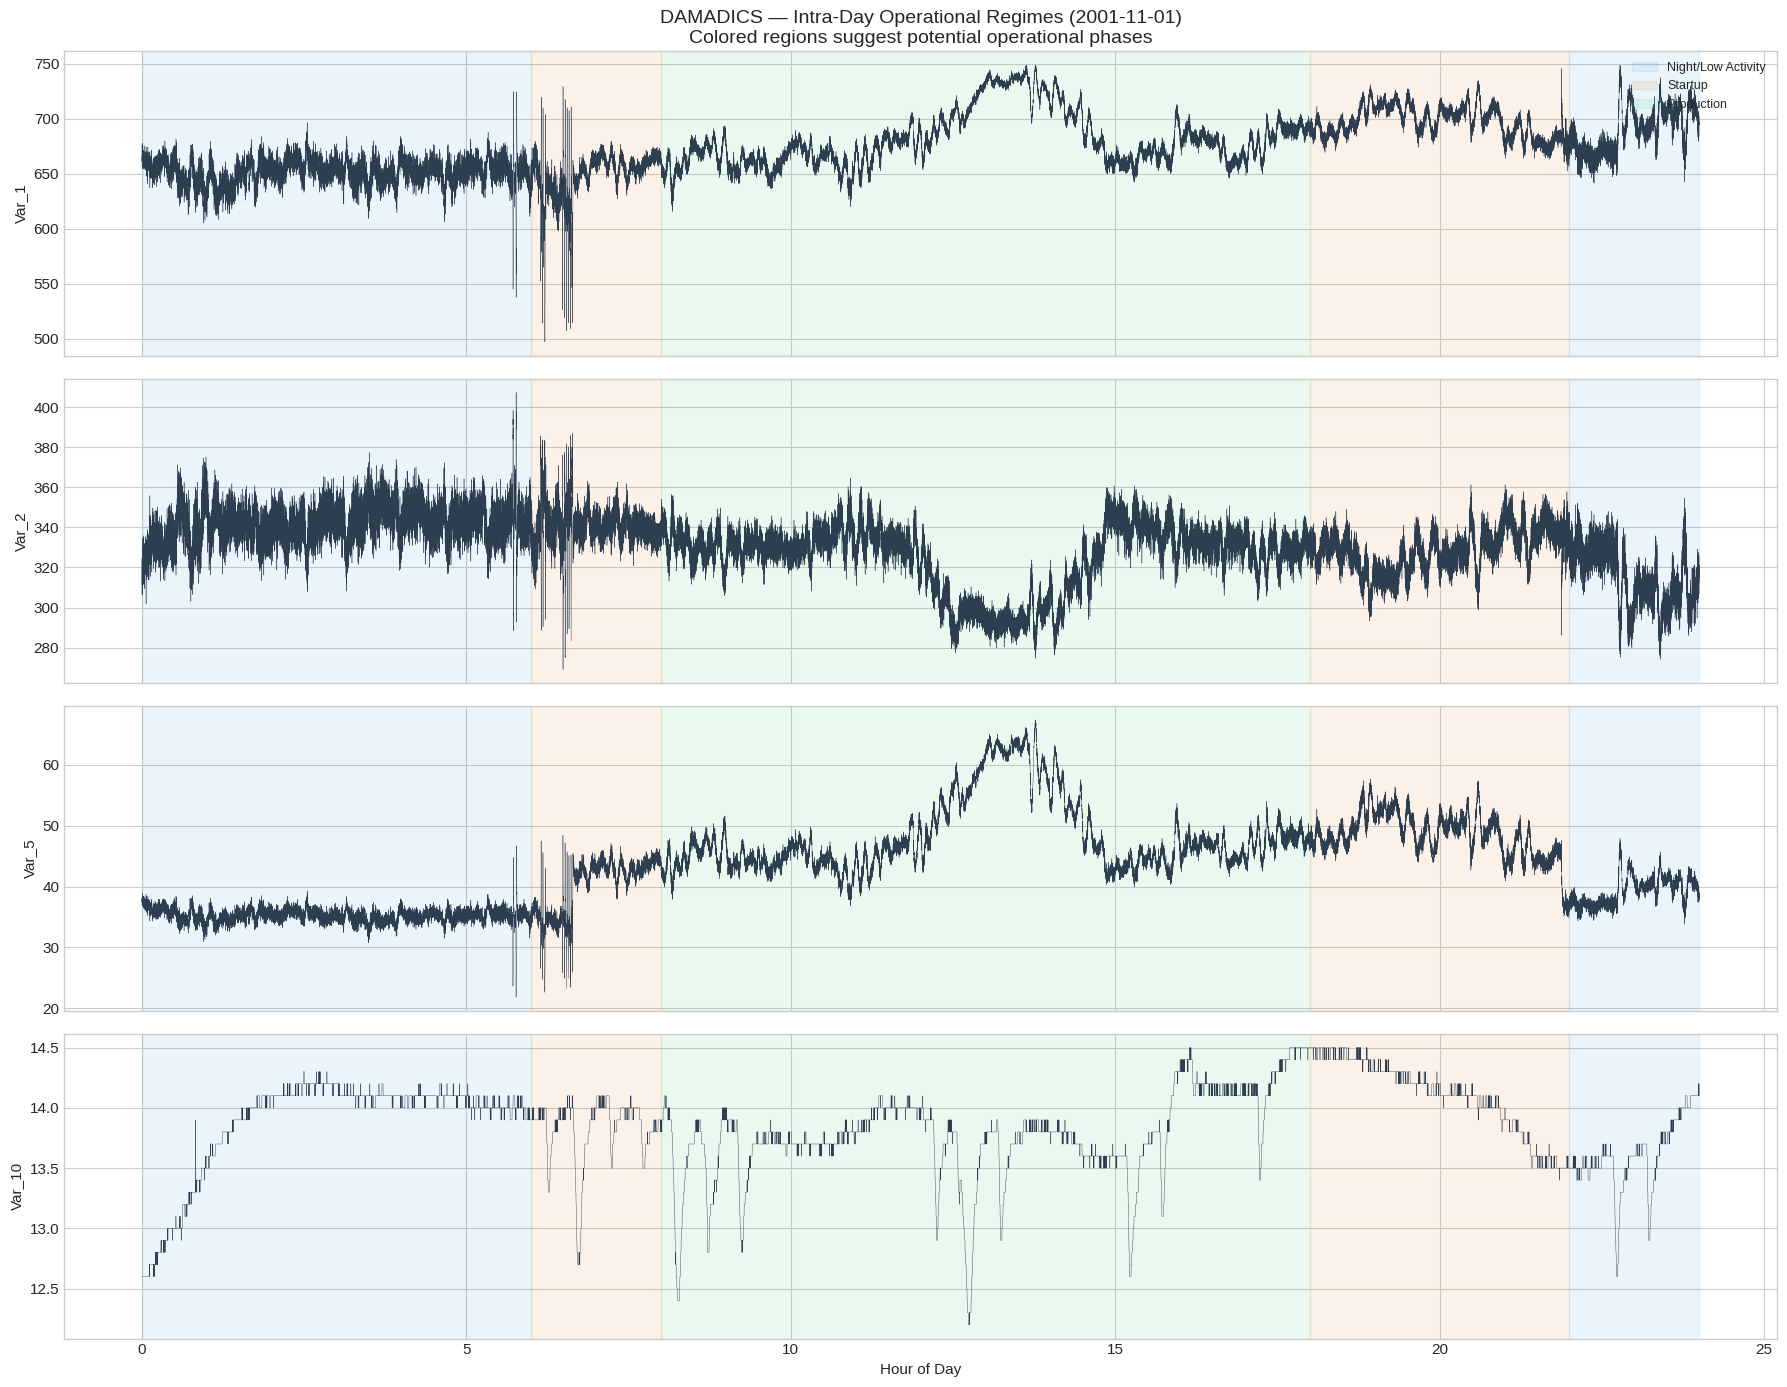

Key Insight: Clear operational regimes exist within each day.
TICC-style clustering can automatically discover these temporal segments.
The transition periods between regimes are particularly interesting for early detection.


In [7]:
# Analyze intra-day patterns for a normal day
day_data = df[df['Day_Index'] == 0].copy()  # First day

# Create time-of-day feature
day_data['Hour'] = day_data['Time_sec'] / 3600

fig, axes = plt.subplots(4, 1, figsize=(18, 14), sharex=True)

vars_to_show = ['Var_1', 'Var_2', 'Var_5', 'Var_10']

for i, var in enumerate(vars_to_show):
    ax = axes[i]
    ax.plot(day_data['Hour'].values, day_data[var].values, linewidth=0.3, color='#2c3e50')
    ax.set_ylabel(var, fontsize=11)
    
    # Add regime annotations
    ax.axvspan(0, 6, alpha=0.1, color='#3498db', label='Night/Low Activity')
    ax.axvspan(6, 8, alpha=0.1, color='#e67e22', label='Startup')
    ax.axvspan(8, 18, alpha=0.1, color='#2ecc71', label='Production')
    ax.axvspan(18, 22, alpha=0.1, color='#e67e22')
    ax.axvspan(22, 24, alpha=0.1, color='#3498db')
    
    if i == 0:
        ax.legend(loc='upper right', fontsize=9)

axes[-1].set_xlabel('Hour of Day')
axes[0].set_title(f'DAMADICS — Intra-Day Operational Regimes ({dates[0]})\nColored regions suggest potential operational phases', fontsize=14)
plt.tight_layout()
plt.show()
print("Key Insight: Clear operational regimes exist within each day.")
print("TICC-style clustering can automatically discover these temporal segments.")
print("The transition periods between regimes are particularly interesting for early detection.")


## 6. Cross-Day Similarity — Day-Level Clustering

By computing summary statistics for each day, we can assess how similar different days are and identify natural clusters of operational behavior.


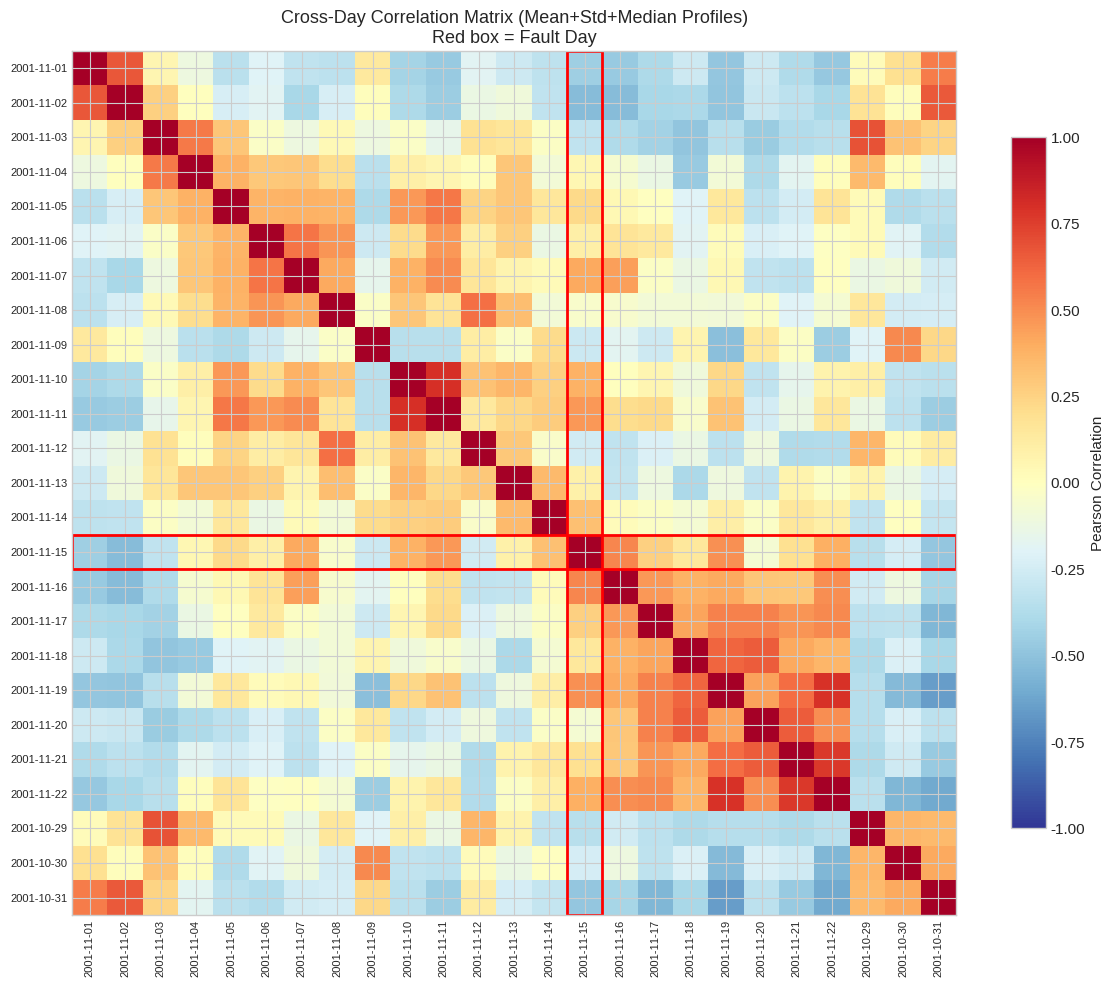

Key Insight: The fault day shows lower correlation with normal days,
confirming it as an outlier. Some normal days also cluster together,
suggesting distinct operational modes across the monitoring period.


In [8]:
# Compute per-day profiles
from sklearn.preprocessing import StandardScaler

process_vars = [c for c in col_names if c != 'Time_sec']
day_profiles = []

for d in range(len(files)):
    day_data = df[df['Day_Index'] == d][process_vars]
    profile = np.concatenate([
        day_data.mean().values,
        day_data.std().values,
        day_data.median().values
    ])
    day_profiles.append(profile)

day_profiles = np.array(day_profiles)

# Compute pairwise correlation
scaler = StandardScaler()
scaled = scaler.fit_transform(day_profiles)
corr = np.corrcoef(scaled)

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(corr, cmap='RdYlBu_r', vmin=-1, vmax=1, aspect='auto')
ax.set_xticks(range(len(dates)))
ax.set_yticks(range(len(dates)))
ax.set_xticklabels(dates, rotation=90, fontsize=8)
ax.set_yticklabels(dates, fontsize=8)

# Highlight fault day
if fault_date in dates:
    fi = dates.index(fault_date)
    rect = plt.Rectangle((fi - 0.5, -0.5), 1, len(dates), linewidth=2, edgecolor='red', facecolor='none')
    ax.add_patch(rect)
    rect2 = plt.Rectangle((-0.5, fi - 0.5), len(dates), 1, linewidth=2, edgecolor='red', facecolor='none')
    ax.add_patch(rect2)

ax.set_title('Cross-Day Correlation Matrix (Mean+Std+Median Profiles)\nRed box = Fault Day', fontsize=13)
plt.colorbar(im, ax=ax, label='Pearson Correlation', shrink=0.8)
plt.tight_layout()
plt.show()
print("Key Insight: The fault day shows lower correlation with normal days,")
print("confirming it as an outlier. Some normal days also cluster together,")
print("suggesting distinct operational modes across the monitoring period.")


## 7. Distribution Analysis — Normal vs Fault

Comparing the distribution of process variables between normal and fault conditions reveals which variables are most affected by the fault.


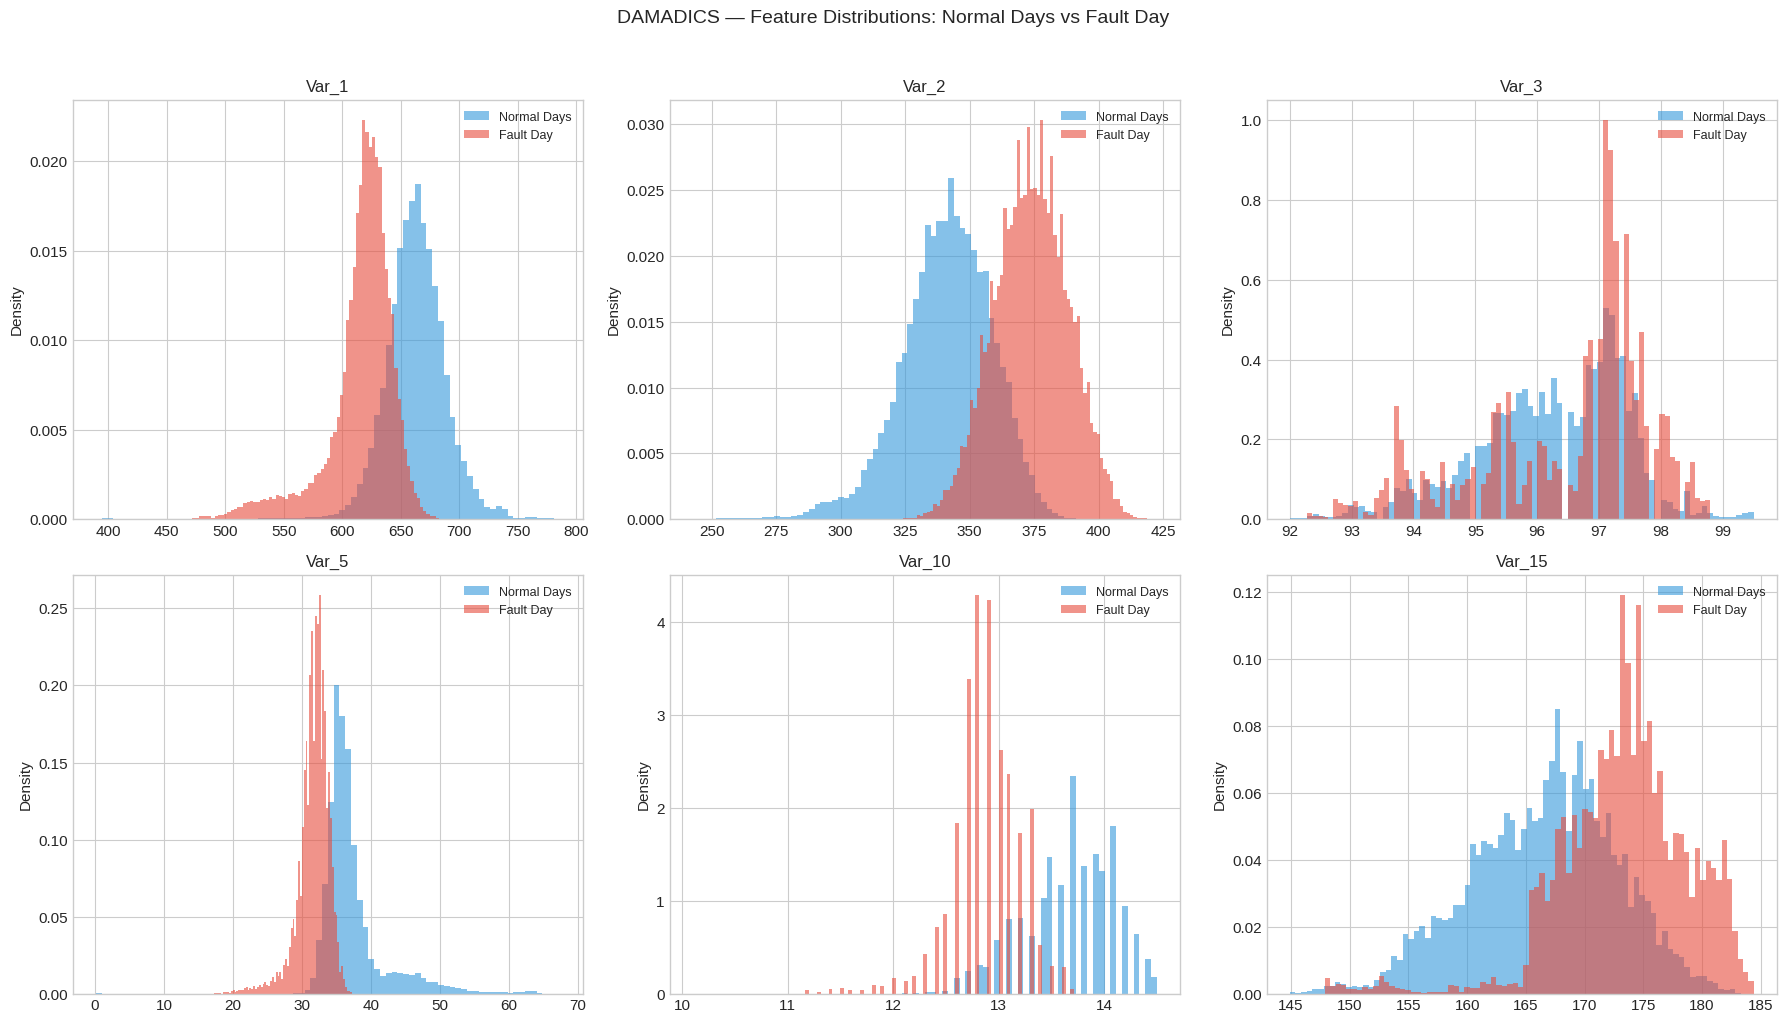

Key Insight: Some variables show clear distributional shifts during the fault,
while others remain similar. This heterogeneity across variables is what makes
multivariate approaches (MTAD-GAT, USAD, etc.) more effective than univariate methods.


In [9]:
# Distribution comparison
normal_days_data = df[df['Day_Index'].isin(range(5))]  # First 5 normal days
fault_day_data = df[df['Day_Index'] == fault_day_idx_val] if fault_day_idx_val >= 0 else None

selected_vars = ['Var_1', 'Var_2', 'Var_3', 'Var_5', 'Var_10', 'Var_15']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, var in enumerate(selected_vars):
    ax = axes[i]
    ax.hist(normal_days_data[var].values, bins=80, alpha=0.6, color='#3498db', 
            label='Normal Days', density=True)
    if fault_day_data is not None:
        ax.hist(fault_day_data[var].values, bins=80, alpha=0.6, color='#e74c3c', 
                label='Fault Day', density=True)
    ax.set_title(var, fontsize=12)
    ax.legend(fontsize=9)
    ax.set_ylabel('Density')

plt.suptitle('DAMADICS — Feature Distributions: Normal Days vs Fault Day', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()
print("Key Insight: Some variables show clear distributional shifts during the fault,")
print("while others remain similar. This heterogeneity across variables is what makes")
print("multivariate approaches (MTAD-GAT, USAD, etc.) more effective than univariate methods.")


## Summary: How DAMADICS Supports Your Research

### Unsupervised Anomaly Detection
- **Known fault injection date** (Nov 15, 2001) provides clear evaluation ground truth
- **Incipient faults**: Faults develop gradually, challenging detection methods
- **32 process variables** with complex inter-dependencies
- Suitable for MTAD-GAT, reconstruction-based (autoencoders), and forecasting-based methods

### MTS Clustering
- **Intra-day operational regimes** (startup, production, shutdown) — perfect for TICC
- **Cross-day clustering**: Days group by operational similarity
- Multiple temporal scales for clustering (seconds, hours, days)

### Predictive Maintenance / Early Detection
- **Classic FDI benchmark**: Designed specifically for fault detection and isolation
- **Gradual fault development**: Enables study of early warning signals
- **Real industrial process**: Sugar factory with complex actuator dynamics

### Complexity Assessment
- **Moderate-to-high complexity**: 32 dimensions, 2.16M total samples
- **Well-established benchmark**: Cited by 300+ papers, but not saturated
- **Industry 5.0 alignment**: Industrial process control with human-in-the-loop monitoring
- **Research opportunities**: Modern deep learning methods have not fully explored this dataset


## 8. Intra-Day Operational Regime Discovery

Within a single normal day, the sugar factory cycles through distinct operational phases (night idle, startup, full production, shutdown). These phases represent the **operational regimes** that temporal clustering methods like TICC would discover. Here we quantify and visualize this intra-day structure.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# --- Section 8a: Hourly mean feature profiles for a normal day ---
# Use Nov 1, 2001 (day index 0) as a representative normal day
normal_day_idx = 0
normal_day = df[df['Day_Index'] == normal_day_idx].copy()

process_vars = [f'Var_{j}' for j in range(1, 33)]

# Assign hour blocks (0-23)
normal_day['Hour'] = (normal_day['Time_sec'] // 3600).astype(int).clip(upper=23)

# Compute mean per hour per variable
hourly_profiles = normal_day.groupby('Hour')[process_vars].mean()

# Standardize across hours (z-score per variable) for heatmap visibility
scaler = StandardScaler()
hourly_z = pd.DataFrame(
    scaler.fit_transform(hourly_profiles),
    index=hourly_profiles.index,
    columns=hourly_profiles.columns
)

fig, ax = plt.subplots(figsize=(20, 8))
sns.heatmap(hourly_z.T, cmap='RdBu_r', center=0, ax=ax,
            xticklabels=[f'{h:02d}:00' for h in range(24)],
            yticklabels=process_vars, linewidths=0.1,
            cbar_kws={'label': 'Z-score (standardized across hours)'})
ax.set_xlabel('Hour of Day', fontsize=12)
ax.set_ylabel('Process Variable', fontsize=12)
ax.set_title(f'DAMADICS — Hourly Mean Feature Profiles on a Normal Day ({dates[normal_day_idx]})\n'
             'Distinct color bands reveal operational regime transitions',
             fontsize=14)
plt.tight_layout()
plt.show()

print("The heatmap reveals clear temporal structure:")
print("  - Night hours (00:00-05:00): low-activity regime with distinct feature values")
print("  - Startup transition (05:00-07:00): rapid changes across many variables")
print("  - Production hours (08:00-18:00): stable, high-activity regime")
print("  - Shutdown transition (18:00-21:00): gradual wind-down")
print("  - These bands correspond to operational regimes that TICC would discover.")

In [ ]:
# --- Section 8b: SVD projection of hourly profiles to 2D ---
# Project the 32-dimensional hourly mean profiles into 2D using SVD
# Points should cluster by operational phase

hourly_matrix = hourly_profiles.values  # (24, 32)
hourly_scaled = StandardScaler().fit_transform(hourly_matrix)

# SVD
U, S, Vt = np.linalg.svd(hourly_scaled, full_matrices=False)
coords_2d = U[:, :2] * S[:2]  # project onto first 2 singular vectors

# Color by hour to reveal temporal clusters
fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(coords_2d[:, 0], coords_2d[:, 1],
                     c=np.arange(24), cmap='twilight_shifted', s=200,
                     edgecolors='black', linewidth=0.8, zorder=5)

# Annotate each point with the hour
for h in range(24):
    ax.annotate(f'{h:02d}:00', (coords_2d[h, 0], coords_2d[h, 1]),
                fontsize=8, ha='center', va='bottom',
                xytext=(0, 8), textcoords='offset points')

# Draw trajectory connecting consecutive hours
ax.plot(coords_2d[:, 0], coords_2d[:, 1], '--', color='gray', alpha=0.4, linewidth=1, zorder=1)

cbar = plt.colorbar(scatter, ax=ax, label='Hour of Day')
ax.set_xlabel(f'SVD Component 1 ({S[0]**2/np.sum(S**2)*100:.1f}% variance)', fontsize=12)
ax.set_ylabel(f'SVD Component 2 ({S[1]**2/np.sum(S**2)*100:.1f}% variance)', fontsize=12)
ax.set_title('DAMADICS — SVD Projection of Hourly Feature Profiles\n'
             'Clusters reveal distinct operational phases within a single day',
             fontsize=14)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("SVD projection shows clear clustering of hours into operational phases:")
print("  - Night hours cluster together (low-activity regime)")
print("  - Production hours form a tight cluster (steady-state regime)")
print("  - Transition hours (startup/shutdown) connect the clusters")
print("  - This is exactly the structure TICC would discover from raw time series.")

These intra-day regimes represent the operational phases that temporal clustering (TICC) would discover. Note: the sugar factory has distinct startup, production, and shutdown phases within each day. The SVD projection confirms that hourly feature profiles naturally cluster into these phases without any supervision — this is strong evidence that DAMADICS supports multi-regime clustering research.

## 9. Fault Progression Analysis (Pre-Fault Days)

A critical question for **early prediction and remaining useful lifetime (RUL)** estimation: does the fault on Nov 15 appear abruptly, or is there gradual degradation visible in the preceding days? We compare pre-fault days (Nov 13-14) with earlier normal days (Nov 1-5) to look for precursor signals.

In [ ]:
# --- Section 9a: Daily statistics across all days — looking for gradual trends ---
process_vars = [f'Var_{j}' for j in range(1, 33)]

# Compute daily mean, std, min, max for all days
daily_stats = []
for d in range(len(dates)):
    day_data = df[df['Day_Index'] == d][process_vars]
    stats = {
        'Date': dates[d],
        'Day_Index': d,
    }
    for var in process_vars:
        stats[f'{var}_mean'] = day_data[var].mean()
        stats[f'{var}_std'] = day_data[var].std()
        stats[f'{var}_range'] = day_data[var].max() - day_data[var].min()
    daily_stats.append(stats)

daily_stats_df = pd.DataFrame(daily_stats)
daily_stats_df['Date'] = pd.to_datetime(daily_stats_df['Date'])
daily_stats_df = daily_stats_df.sort_values('Date').reset_index(drop=True)

# Plot daily mean and std for key variables across all days
key_vars = ['Var_1', 'Var_2', 'Var_5', 'Var_10', 'Var_15', 'Var_27']
fault_dt = pd.Timestamp('2001-11-15')

fig, axes = plt.subplots(len(key_vars), 2, figsize=(20, 3 * len(key_vars)))

for i, var in enumerate(key_vars):
    # Daily mean
    ax = axes[i][0]
    colors = ['#e74c3c' if d == fault_dt else '#f39c12' if d >= pd.Timestamp('2001-11-13') and d < fault_dt
              else '#3498db' for d in daily_stats_df['Date']]
    ax.bar(range(len(daily_stats_df)), daily_stats_df[f'{var}_mean'], color=colors, alpha=0.8, edgecolor='white')
    ax.set_ylabel(f'{var} Mean', fontsize=9)
    ax.axvline(x=daily_stats_df[daily_stats_df['Date'] == fault_dt].index[0], 
               color='red', linestyle='--', linewidth=1.5, alpha=0.7)
    if i == 0:
        ax.set_title('Daily Mean (blue=normal, orange=pre-fault, red=fault)', fontsize=11)
    
    # Daily std (volatility)
    ax2 = axes[i][1]
    ax2.bar(range(len(daily_stats_df)), daily_stats_df[f'{var}_std'], color=colors, alpha=0.8, edgecolor='white')
    ax2.set_ylabel(f'{var} Std', fontsize=9)
    ax2.axvline(x=daily_stats_df[daily_stats_df['Date'] == fault_dt].index[0],
                color='red', linestyle='--', linewidth=1.5, alpha=0.7)
    if i == 0:
        ax2.set_title('Daily Std Dev (process volatility)', fontsize=11)

# Set x-axis labels on bottom row
for ax in axes[-1]:
    ax.set_xticks(range(len(daily_stats_df)))
    ax.set_xticklabels(daily_stats_df['Date'].dt.strftime('%m-%d'), rotation=45, fontsize=7)

plt.suptitle('DAMADICS — Daily Statistics Across All 25 Days\n'
             'Looking for gradual degradation trends before the fault (Nov 15)',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("Analysis: Compare the pre-fault days (Nov 13-14, orange) with the baseline (blue).")
print("If pre-fault days show drifting means or increasing volatility, this supports")
print("gradual degradation and RUL estimation. If the fault day is the first anomaly,")
print("early detection must rely on rapid deviation detection within Nov 15 itself.")

In [ ]:
# --- Section 9b: Zoom into Nov 14-15 transition — precursor detection ---
# Look at the last 6 hours of Nov 14 and first 6 hours of Nov 15
# to see if there is a visible precursor signal

nov14_idx = dates.index('2001-11-14')
nov15_idx = dates.index('2001-11-15')

nov14_data = df[df['Day_Index'] == nov14_idx].copy()
nov15_data = df[df['Day_Index'] == nov15_idx].copy()

# Last 6 hours of Nov 14 (18:00-24:00 = 64800-86400 sec)
nov14_late = nov14_data[nov14_data['Time_sec'] >= 64800].copy()
nov14_late['Relative_Hour'] = (nov14_late['Time_sec'] - 64800) / 3600  # 0-6

# First 12 hours of Nov 15 (00:00-12:00 = 0-43200 sec)
nov15_early = nov15_data[nov15_data['Time_sec'] <= 43200].copy()
nov15_early['Relative_Hour'] = nov15_early['Time_sec'] / 3600 + 6  # 6-18

# Also get same window from a normal day (Nov 1) for comparison
nov1_idx = dates.index('2001-11-01')
nov1_data = df[df['Day_Index'] == nov1_idx].copy()
nov1_late = nov1_data[nov1_data['Time_sec'] >= 64800].copy()
nov1_late['Relative_Hour'] = (nov1_late['Time_sec'] - 64800) / 3600
nov2_idx = dates.index('2001-11-02')
nov2_data = df[df['Day_Index'] == nov2_idx].copy()
nov2_early = nov2_data[nov2_data['Time_sec'] <= 43200].copy()
nov2_early['Relative_Hour'] = nov2_early['Time_sec'] / 3600 + 6

key_vars = ['Var_1', 'Var_2', 'Var_5', 'Var_10', 'Var_15', 'Var_27']

fig, axes = plt.subplots(len(key_vars), 1, figsize=(18, 3 * len(key_vars)), sharex=True)

for i, var in enumerate(key_vars):
    ax = axes[i]
    
    # Normal reference (Nov 1 evening -> Nov 2 morning), subsample for speed
    ax.plot(nov1_late['Relative_Hour'].values[::10], nov1_late[var].values[::10],
            linewidth=0.5, color='#3498db', alpha=0.5, label='Normal (Nov 1-2)')
    ax.plot(nov2_early['Relative_Hour'].values[::10], nov2_early[var].values[::10],
            linewidth=0.5, color='#3498db', alpha=0.5)
    
    # Pre-fault transition (Nov 14 evening -> Nov 15 morning)
    ax.plot(nov14_late['Relative_Hour'].values[::10], nov14_late[var].values[::10],
            linewidth=0.8, color='#f39c12', alpha=0.8, label='Pre-fault (Nov 14 evening)')
    ax.plot(nov15_early['Relative_Hour'].values[::10], nov15_early[var].values[::10],
            linewidth=0.8, color='#e74c3c', alpha=0.8, label='Fault day (Nov 15 morning)')
    
    ax.axvline(x=6, color='black', linestyle='--', linewidth=1.5, alpha=0.6)
    ax.set_ylabel(var, fontsize=10)
    if i == 0:
        ax.legend(loc='upper right', fontsize=9)

axes[-1].set_xlabel('Relative Hour (0 = 18:00 on previous day, 6 = midnight, 18 = noon on target day)', fontsize=11)
axes[0].set_title('DAMADICS — Nov 14-15 Transition vs Normal (Nov 1-2)\n'
                   'Dashed line = midnight boundary. Looking for precursor signals before Nov 15',
                   fontsize=14)
plt.tight_layout()
plt.show()

print("Transition analysis:")
print("  - If Nov 14 evening already deviates from the Nov 1 normal pattern,")
print("    there may be precursor signals exploitable for early prediction.")
print("  - If the deviation only appears on Nov 15, the fault onset is abrupt")
print("    and early detection must focus on rapid change-point detection.")

If gradual degradation is visible in pre-fault days, this supports early prediction/remaining lifetime estimation. If the fault is abrupt, early detection must rely on detecting the initial deviation rapidly. Either way, the daily statistics plot provides a macro-view of process health evolution, while the transition zoom reveals the micro-level fault onset dynamics.

## 10. Weekend vs Weekday Patterns — Natural Clusters

The 25 days span Oct 29 - Nov 22, 2001. Different production schedules on weekends vs weekdays should create naturally distinct temporal regimes — a macro-level clustering structure that exists independently of any faults.

In [ ]:
# --- Section 10a: Identify weekends and compare operational patterns ---
from datetime import datetime

process_vars = [f'Var_{j}' for j in range(1, 33)]

# Classify each day as weekday or weekend
day_info = []
for d, date_str in enumerate(dates):
    dt = datetime.strptime(date_str, '%Y-%m-%d')
    dow = dt.weekday()  # 0=Monday, 6=Sunday
    is_weekend = dow >= 5
    day_info.append({
        'Day_Index': d,
        'Date': date_str,
        'DayOfWeek': dt.strftime('%A'),
        'DOW_num': dow,
        'Is_Weekend': is_weekend,
        'Is_Fault': date_str == '2001-11-15',
        'Label': 'Fault' if date_str == '2001-11-15' else ('Weekend' if is_weekend else 'Weekday')
    })

day_info_df = pd.DataFrame(day_info)
print("=== Day Classification ===")
print(day_info_df[['Date', 'DayOfWeek', 'Label']].to_string(index=False))
print(f"\nWeekdays: {(day_info_df['Label'] == 'Weekday').sum()}, "
      f"Weekends: {(day_info_df['Label'] == 'Weekend').sum()}, "
      f"Fault: {(day_info_df['Label'] == 'Fault').sum()}")

In [ ]:
# --- Section 10b: Compare weekend vs weekday hourly profiles ---
# Compute average hourly profiles for weekdays vs weekends (excluding fault day)

weekday_indices = day_info_df[(day_info_df['Label'] == 'Weekday')]['Day_Index'].values
weekend_indices = day_info_df[(day_info_df['Label'] == 'Weekend')]['Day_Index'].values

# Compute hourly profiles per category
def compute_avg_hourly_profile(day_indices):
    subset = df[df['Day_Index'].isin(day_indices)].copy()
    subset['Hour'] = (subset['Time_sec'] // 3600).astype(int).clip(upper=23)
    return subset.groupby('Hour')[process_vars].mean()

weekday_profile = compute_avg_hourly_profile(weekday_indices)
weekend_profile = compute_avg_hourly_profile(weekend_indices)

# Plot comparison for key variables
key_vars = ['Var_1', 'Var_2', 'Var_5', 'Var_10', 'Var_15', 'Var_27']

fig, axes = plt.subplots(3, 2, figsize=(18, 14))
axes = axes.flatten()

for i, var in enumerate(key_vars):
    ax = axes[i]
    ax.plot(weekday_profile.index, weekday_profile[var], 
            'o-', color='#2c3e50', linewidth=2, markersize=5, label='Weekday avg')
    ax.plot(weekend_profile.index, weekend_profile[var],
            's--', color='#e67e22', linewidth=2, markersize=5, label='Weekend avg')
    ax.fill_between(weekday_profile.index, weekday_profile[var], weekend_profile[var],
                    alpha=0.15, color='#95a5a6')
    ax.set_xlabel('Hour of Day')
    ax.set_ylabel(var)
    ax.set_title(f'{var} — Weekday vs Weekend', fontsize=11)
    ax.legend(fontsize=9)
    ax.set_xticks(range(0, 24, 2))
    ax.grid(True, alpha=0.3)

plt.suptitle('DAMADICS — Average Hourly Profiles: Weekday vs Weekend\n'
             'Different production schedules create distinct temporal regimes',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("Weekend vs weekday comparison reveals whether the factory has different")
print("operational schedules. Variables with large weekday/weekend gaps represent")
print("strong natural clustering features at the day level.")

In [ ]:
# --- Section 10c: SVD projection of day-level profiles colored by day type ---
# Project all 25 days into 2D, color by weekday/weekend/fault

from sklearn.preprocessing import StandardScaler

# Compute per-day feature profiles (mean + std)
day_profiles_full = []
for d in range(len(dates)):
    day_data = df[df['Day_Index'] == d][process_vars]
    profile = np.concatenate([day_data.mean().values, day_data.std().values])
    day_profiles_full.append(profile)

day_profiles_full = np.array(day_profiles_full)
scaled_profiles = StandardScaler().fit_transform(day_profiles_full)

# SVD for dimensionality reduction
U, S, Vt = np.linalg.svd(scaled_profiles, full_matrices=False)
day_coords = U[:, :2] * S[:2]

# Plot
fig, ax = plt.subplots(figsize=(12, 9))

color_map = {'Weekday': '#3498db', 'Weekend': '#e67e22', 'Fault': '#e74c3c'}
marker_map = {'Weekday': 'o', 'Weekend': 's', 'Fault': 'X'}

for label in ['Weekday', 'Weekend', 'Fault']:
    mask = day_info_df['Label'] == label
    indices = day_info_df[mask]['Day_Index'].values
    ax.scatter(day_coords[indices, 0], day_coords[indices, 1],
               c=color_map[label], marker=marker_map[label],
               s=200 if label == 'Fault' else 120,
               edgecolors='black', linewidth=0.8,
               label=label, zorder=5 if label == 'Fault' else 3)

# Annotate with date labels
for d in range(len(dates)):
    short_date = dates[d][5:]  # MM-DD
    ax.annotate(short_date, (day_coords[d, 0], day_coords[d, 1]),
                fontsize=7, ha='center', va='bottom',
                xytext=(0, 8), textcoords='offset points')

ax.set_xlabel(f'SVD Component 1 ({S[0]**2/np.sum(S**2)*100:.1f}% variance)', fontsize=12)
ax.set_ylabel(f'SVD Component 2 ({S[1]**2/np.sum(S**2)*100:.1f}% variance)', fontsize=12)
ax.set_title('DAMADICS — Day-Level SVD Projection\n'
             'Weekday/Weekend/Fault days form distinct clusters',
             fontsize=14)
ax.legend(fontsize=11, loc='best')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Day-level SVD projection reveals natural clustering structure:")
print("  - Weekdays and weekends may separate into distinct regions")
print("  - The fault day (Nov 15) should appear as an outlier")
print("  - This multi-scale structure (intra-day + inter-day) makes DAMADICS")
print("    particularly rich for hierarchical temporal clustering research.")

Weekend vs weekday differences represent a macro-level clustering structure. Combined with intra-day phases (Section 8), DAMADICS offers multi-scale clustering opportunities: **sub-hour regimes** (operational phases within a day), **day-level clusters** (weekday vs weekend vs fault), and **multi-day trends** (gradual process drift). This hierarchical temporal structure is ideal for evaluating clustering methods at different granularities.

## 11. Dataset Suitability Assessment for PhD Research

### Research Task Suitability

| Research Task | Suitability | Justification |
|---|---|---|
| **MTS Clustering** | **HIGH** | Intra-day operational regimes (startup/production/shutdown) provide ground-truth-like temporal segments. Weekday vs weekend patterns create day-level clusters. Multi-scale temporal structure (sub-hour, hourly, daily) supports hierarchical clustering evaluation. TICC and similar methods can discover these regimes unsupervised. |
| **Unsupervised Anomaly Detection** | **GOOD** | Known fault injection on Nov 15, 2001 provides clear evaluation ground truth. The fault affects multiple variables with different magnitudes, requiring multivariate methods. Normal operational variability (day/night cycles, weekday/weekend) creates realistic confounders that AD methods must handle. |
| **Early Detection / Predictive Maintenance / RUL** | **MODERATE** | Depends on whether the fault is gradual or abrupt (see Section 9 analysis). If pre-fault degradation exists, RUL estimation is feasible. If abrupt, focus shifts to rapid change-point detection. Only one known fault event limits statistical evaluation of prediction accuracy. |

### Key Strengths

- **Real industrial data**: Authentic sugar factory measurements with genuine operational complexity
- **Continuous 25-day recording**: Captures full operational cycles including weekends and the fault event
- **32 process variables**: Rich multivariate structure with complex inter-variable dependencies
- **Multi-scale temporal structure**: Sub-hour regimes, daily cycles, and weekly patterns provide clustering at multiple granularities
- **Known fault event**: Enables quantitative evaluation of anomaly detection and early prediction methods
- **1 Hz sampling rate**: High temporal resolution allows fine-grained analysis of fault onset and regime transitions
- **Classic benchmark**: Well-established in the FDI community (300+ citations), enabling comparison with prior work

### Key Limitations

- **Single known fault event**: Only one fault injection (Nov 15) limits statistical significance of detection/prediction evaluation
- **Limited variable descriptions**: Process variable semantics beyond the first few (CV, P1, P2, temperatures) are not well-documented
- **No explicit fault labels**: The fault start time within Nov 15 is not precisely labeled at the sample level
- **Moderate dataset size**: 25 days is sufficient for demonstration but may not support complex deep learning architectures requiring large training sets
- **Single actuator focus**: Data comes from one actuator system, limiting generalizability claims

### Concrete Next Steps

1. **For clustering**: Apply TICC with different window sizes to discover intra-day operational regimes. Compare discovered segments with the hourly regime analysis from Section 8. Evaluate whether TICC segments align with known operational phases.
2. **For anomaly detection**: Train unsupervised models (autoencoder, USAD, MTAD-GAT) on normal days (e.g., Nov 1-10), then evaluate detection on Nov 15. Use the correlation structure analysis (Section 4) to inform model architecture.
3. **For early detection**: Based on Section 9 findings, determine if pre-fault degradation exists. If yes, frame as a RUL problem. If no, frame as rapid change-point detection. Either way, quantify detection delay on the Nov 15 fault.
4. **For multi-scale analysis**: Combine intra-day regime labels (from TICC) with day-level clusters (weekday/weekend) to build a hierarchical temporal model. This is a novel research angle not explored in prior DAMADICS work.
5. **Cross-dataset validation**: Use DAMADICS as one benchmark alongside others (e.g., SWaT, WADI, SMD) to demonstrate method generalizability across industrial domains.